In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/processed/model_laptop_data.csv')


# Laptop Price Regression Notebook

This notebook builds and evaluates regression models to predict laptop price.

## Notebook Flow
1. Feature understanding and preparation.
2. Baseline multiple linear regression pipeline.
3. Diagnostics and OLS-based statistical validation.

In [13]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price               1.000000
Ram                 0.743007
X_res               0.556529
Y_res               0.552809
Is_Gaming_Laptop    0.375789
Ips                 0.252208
Weight              0.210370
Touchscreen         0.191226
Inches              0.068197
Name: Price, dtype: float64

In [14]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')


In [16]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price               1.000000
Ram                 0.743007
X_res               0.556529
Y_res               0.552809
ppi                 0.473487
Is_Gaming_Laptop    0.375789
Ips                 0.252208
Weight              0.210370
Touchscreen         0.191226
Inches              0.068197
Name: Price, dtype: float64

In [17]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [18]:
df.head()


,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,X_res,Y_res,ppi
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,2560,1600,226.983005
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,2880,1800,220.534624
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,2560,1600,226.983005


In [19]:
df.drop(columns=['Inches','X_res','Y_res'],inplace=True)


In [20]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,226.983005


In [21]:
df['Cpu'].value_counts()


Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [22]:
df['Cpu Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))


In [23]:
df.head()


,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,ppi,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,226.983005,Intel Core i5


In [24]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [25]:
df['Cpu brand'] = df['Cpu Name'].apply(fetch_processor)

In [26]:
df.head()


,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,Processor_Family,Is_Gaming_Laptop,Ips,Touchscreen,ppi,Cpu Name,Cpu brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel Core i5,False,1,0,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel Core i5,False,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel Core i5,False,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,Intel Core i7,False,1,0,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel Core i5,False,1,0,226.983005,Intel Core i5,Intel Core i5


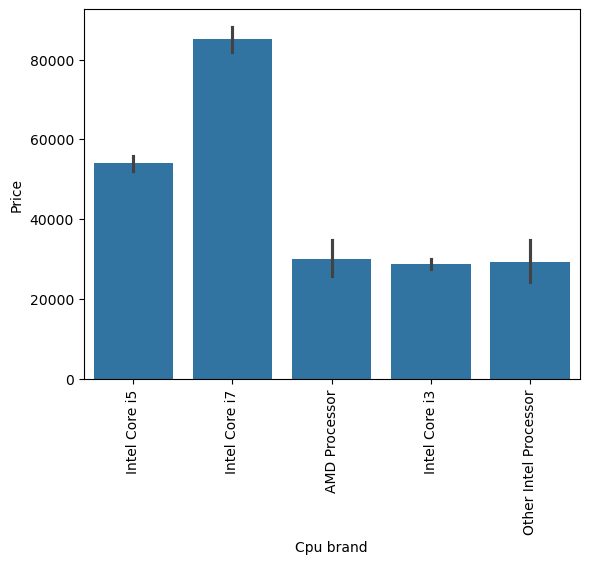

In [27]:
sns.barplot(x=df['Cpu brand'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

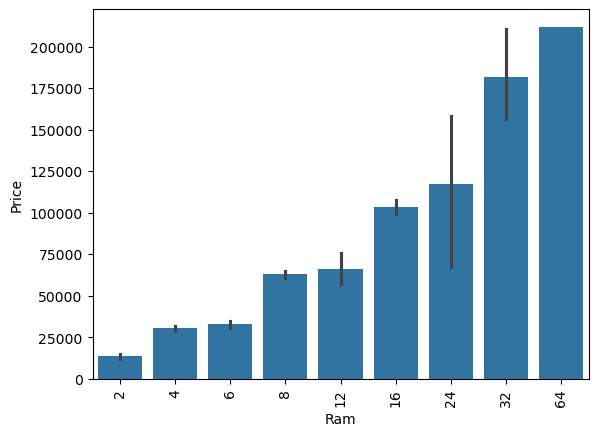

In [28]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()


In [29]:
df['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [31]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Processor_Brand,...,first,second,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash_Storage,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2Flash_Storage
607,Lenovo,Notebook,Intel Core i5 7200U 2.5GHz,6,1000 HDD,Intel HD Graphics 620,Windows 10,2.40,30049.920,Intel,...,1000 HDD,0,1,0,0,0,0,0,0,0
925,Dell,Notebook,Intel Core i5 6200U 2.3GHz,4,500 HDD,Intel HD Graphics 520,Windows 10,1.95,38889.072,Intel,...,500 HDD,0,1,0,0,0,0,0,0,0
231,HP,Notebook,AMD E-Series 9000e 1.5GHz,4,500 HDD,AMD Radeon R2,Windows 10,2.10,17582.400,AMD,...,500 HDD,0,1,0,0,0,0,0,0,0
788,Acer,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256 SSD + 1000 HDD,Nvidia GeForce GTX 1060,Windows 10,4.20,122490.720,Intel,...,256 SSD,1000 HDD,0,1,0,0,1,0,0,0
168,Acer,Notebook,Intel Core i5 8250U 1.6GHz,8,256 SSD,Nvidia GeForce MX150,Windows 10,3.00,45501.120,Intel,...,256 SSD,0,0,1,0,0,0,0,0,0


## 1) Model Selection Rationale

The target variable is continuous (**Price**), so the task is a supervised regression problem.

This notebook uses **Multiple Linear Regression** as an interpretable baseline and then validates with **OLS** for deeper statistical insight.

## 2) Training Workflow (Visual)

```mermaid
flowchart TD
    A[Load model-ready dataset] --> B[Define features X and target y (Price)]
    B --> C[Split data into train/test (70/30)]
    C --> D[Preprocess numeric and categorical features]
    D --> E[Train linear regression model]
    E --> F[Predict on test set]
    F --> G[Evaluate metrics: MAE, RMSE, R²]
    G --> H[Run diagnostics and OLS validation]
```

In [ ]:
# Multiple Linear Regression: sequential 70/30 split
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_df = pd.read_csv('data/processed/cleaned_laptop_data.csv').copy()

# Ensure numeric dtypes for columns that may be read as object
model_df['Ram'] = model_df['Ram'].astype(str).str.replace('GB', '', regex=False).astype(float)
model_df['Weight'] = model_df['Weight'].astype(str).str.replace('kg', '', regex=False).astype(float)

X = model_df.drop(columns=['Price'])
y = model_df['Price']

split_idx = int(len(model_df) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

print(f'Train size: {len(X_train)} rows')
print(f'Test size: {len(X_test)} rows')

Train size: 912 rows
Test size: 391 rows


In [34]:
# Train model and evaluate accuracy
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# MAPE with safe divide
safe_actual = np.where(y_test.to_numpy() == 0, np.nan, y_test.to_numpy())
mape = np.nanmean(np.abs((y_test.to_numpy() - y_pred) / safe_actual)) * 100

print('Multiple Linear Regression Performance (Test Set)')
print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

Multiple Linear Regression Performance (Test Set)
MAE  : 12,942.78
RMSE : 19,211.08
R²   : 0.7078
MAPE : 22.29%


In [35]:
# Actual vs predicted sample
results_df = pd.DataFrame({
    'Actual Price': y_test.to_numpy(),
    'Predicted Price': y_pred,
    'Residual': y_test.to_numpy() - y_pred
})
results_df.head(10)

,Actual Price,Predicted Price,Residual
0,42037.9200,50836.228810,-8798.308810
1,54291.7872,60100.656294,-5808.869094
2,26586.7200,22325.281329,4261.438671
3,46939.6800,42910.205302,4029.474698
4,51148.8000,52285.369163,-1136.569163
5,85194.7200,72953.662287,12241.057713
6,71874.7200,75520.678226,-3645.958226
7,59668.8048,60524.264401,-855.459601
8,36496.2672,30979.177704,5517.089496
9,69103.6272,68482.008480,621.618720


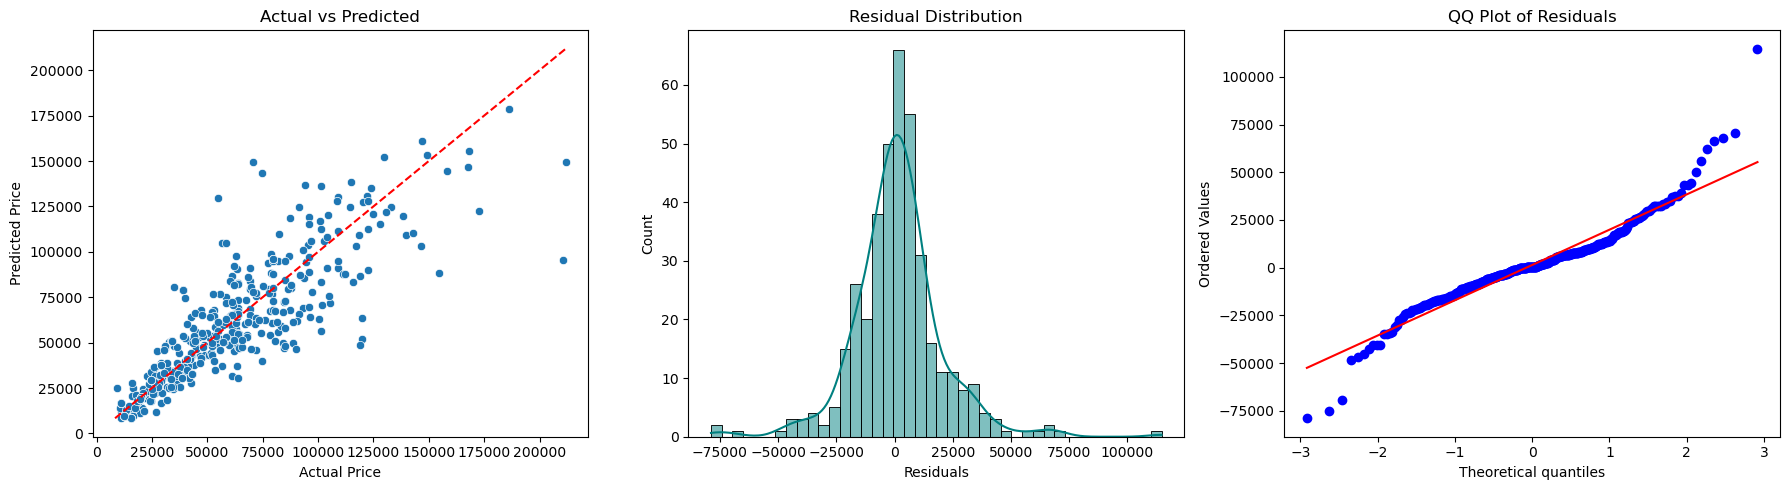

In [36]:
# Model diagnostics: Predicted vs Actual, Residual distribution, and QQ plot
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=results_df, x='Actual Price', y='Predicted Price', ax=axes[0])
min_val = min(results_df['Actual Price'].min(), results_df['Predicted Price'].min())
max_val = max(results_df['Actual Price'].max(), results_df['Predicted Price'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted')

sns.histplot(results_df['Residual'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residuals')

stats.probplot(results_df['Residual'], dist='norm', plot=axes[2])
axes[2].set_title('QQ Plot of Residuals')

plt.tight_layout()
plt.show()

## 3) OLS Validation and Interpretation

OLS metrics summarize generalization on the test set:
- **R²**: proportion of explained variance.
- **MAE**: average absolute prediction error.
- **RMSE**: error metric that penalizes larger misses more strongly.

Higher **R²** and lower **MAE/RMSE** indicate better predictive quality when considered alongside residual diagnostics.

In [39]:
# OLS model summary (statsmodels) using the same 70/30 split
import statsmodels.api as sm

X_ols_full = pd.get_dummies(X, drop_first=True)
X_train_ols = X_ols_full.iloc[:split_idx]
X_test_ols = X_ols_full.iloc[split_idx:]

y_train_ols = y.iloc[:split_idx].astype(float)
y_test_ols = y.iloc[split_idx:].astype(float)

X_train_ols_const = sm.add_constant(X_train_ols, has_constant='add').astype(float)
X_test_ols_const = sm.add_constant(X_test_ols, has_constant='add').astype(float)

ols_model = sm.OLS(y_train_ols, X_train_ols_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     36.39
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          7.59e-276
Time:                        18:59:15   Log-Likelihood:                -9658.8
No. Observations:                 912   AIC:                         1.984e+04
Df Residuals:                     651   BIC:                         2.110e+04
Df Model:                         260                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [40]:
# OLS test-set metrics
ols_pred = ols_model.predict(X_test_ols_const)
ols_mae = mean_absolute_error(y_test_ols, ols_pred)
ols_rmse = np.sqrt(mean_squared_error(y_test_ols, ols_pred))
ols_r2 = r2_score(y_test_ols, ols_pred)

print('OLS Performance (Test Set)')
print(f'MAE  : {ols_mae:,.2f}')
print(f'RMSE : {ols_rmse:,.2f}')
print(f'R²   : {ols_r2:.4f}')

OLS Performance (Test Set)
MAE  : 12,900.03
RMSE : 19,084.86
R²   : 0.7116
